**To Do:**
- NI for 2nd gradient plot
- Label right y axes
- Find mineral of common unaccounted peak

In [28]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

In [3]:
# Define gaussian filter subtraction and smoothing function
def gauss_sub(i):
    g = gaussian_filter1d(i,sigma=50)
    isub = i-g
    y = gaussian_filter1d(isub,sigma=2)
    return y

# Define second gradient function
def second_gradient(i):
    di = np.gradient(i)
    y = gaussian_filter1d(-np.gradient(di),sigma=2)
    return y

# Define function to get x and y position of peaks
def peaks(r,y,h):
    p = find_peaks(y,height=h,distance=20)
    ph = p[1]['peak_heights']
    pp = r[p[0]]
    return pp,ph

In [4]:
# Import data and define variables
n1a = np.genfromtxt('Data/NN01_260130_Map_Average.txt',delimiter='\t')
n1r = n1a[:-75,0]
n1i = n1a[:-75,1]
n1y = gauss_sub(n1i)
n1yy = second_gradient(n1i)
pg1p,pg1h = peaks(n1r,n1y,30)
p21p,p21h = peaks(n1r,n1yy,5)

n2a = np.genfromtxt('Data/NN02_260128_Map_Average.txt',delimiter='\t')
n2r = n2a[:-75,0]
n2i = n2a[:-75,1]
n2y = gauss_sub(n2i)
n2yy = second_gradient(n2i)
pg2p,pg2h = peaks(n2r,n2y,60)
p22p,p22h = peaks(n2r,n2yy,2)

n3a = np.genfromtxt('Data/NN03_260130_Map_Average.txt',delimiter='\t')
n3r = n3a[:-75,0]
n3i = n3a[:-75,1]
n3y = gauss_sub(n3i)
n3yy = second_gradient(n3i)
pg3p,pg3h = peaks(n3r,n3y,20)
p23p,p23h = peaks(n3r,n3yy,2)

n4aa = np.genfromtxt('Data/NN04a_260306_MAP_20x20_Average.txt',delimiter='\t')
n4ar = n4aa[:-75,0]
n4ai = n4aa[:-75,1]
n4ay = gauss_sub(n4ai)
n4ayy = second_gradient(n4ai)
pg4ap,pg4ah = peaks(n4ar,n4ay,50)
p24ap,p24ah = peaks(n4ar,n4ayy,1)

n4ba = np.genfromtxt('Data/NN04b_260306_MAP_20x20_Average.txt',delimiter='\t')
n4br = n4ba[:-75,0]
n4bi = n4ba[:-75,1]
n4by = gauss_sub(n4bi)
n4byy = second_gradient(n4bi)
pg4bp,pg4bh = peaks(n4br,n4by,20)
p24bp,p24bh = peaks(n4br,n4byy,1)

n5a = np.genfromtxt('Data/NN05_260130_Map_Average.txt',delimiter='\t')
n5r = n5a[:-75,0]
n5i = n5a[:-75,1]
n5y = gauss_sub(n5i)
n5yy = second_gradient(n5i)
pg5p,pg5h = peaks(n5r,n5y,50)
p25p,p25h = peaks(n5r,n5yy,2)

n6a = np.genfromtxt('Data/NN06_260130_Map_Average.txt',delimiter='\t')
n6r = n6a[:-75,0]
n6i = n6a[:-75,1]
n6y = gauss_sub(n6i)
n6yy = second_gradient(n6i)
pg6p,pg6h = peaks(n6r,n6y,30)
p26p,p26h = peaks(n6r,n6yy,2.5)

n7ba = np.genfromtxt('Data/NN07b_260306_MAP_20x20_Average.txt',delimiter='\t')
n7br = n7ba[:-75,0]
n7bi = n7ba[:-75,1]
n7by = gauss_sub(n7bi)
n7byy = second_gradient(n7bi)
pg7bp,pg7bh = peaks(n7br,n7by,30)
p27bp,p27bh = peaks(n7br,n7byy,1.2)

k = np.genfromtxt('Data/M08_Kaolin_MapAvr_25-08-14.txt',delimiter='\t')
kr = k[:-75,0]
ki = k[:-75,1]
ky = gauss_sub(ki)
kyy = second_gradient(ki)
pgkp,pgkh = peaks(kr,ky,85)
p2kp,p2kh = peaks(kr,kyy,2)

h = np.genfromtxt('Data/RRUFF_Hematite_R060190_Eng.txt',delimiter=', ')
hr = h[:-75,0]
hi = h[:-75,1]
hy = gauss_sub(hi)
hyy = second_gradient(hi)
pghp,pghh = peaks(hr,hy,20)
p2hp,p2hh = peaks(hr,hyy,7)

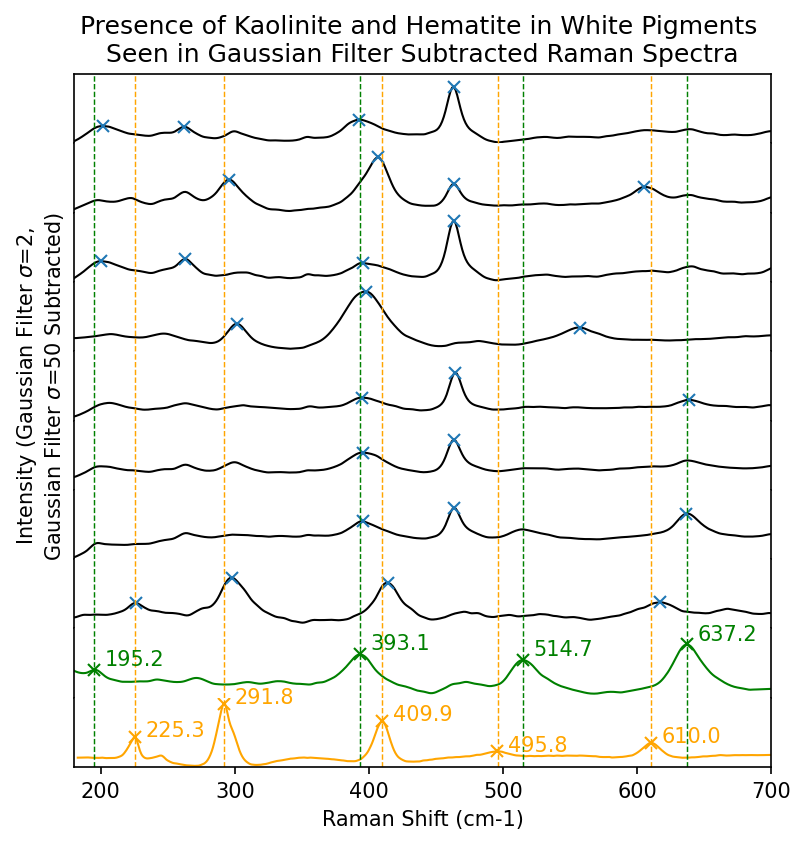

In [29]:
plt.rcParams['figure.dpi'] = 150
plt.figure(figsize=(6,6)) 
plt.subplots_adjust(hspace=0)

plt.subplot(10,1,1)
frame1 = plt.gca()
plt.plot(n1r,n1y,c='Black',linewidth=1)
plt.plot(pg1p,pg1h,"x")
plt.xlim(180,700)
plt.ylim(-50,300)
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])
frame1.spines['bottom'].set_visible(False)
plt.title('Presence of Kaolinite and Hematite in White Pigments \nSeen in Gaussian Filter Subtracted Raman Spectra')
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,2)
frame2 = plt.gca()
plt.plot(n2r,n2y,c='Black',linewidth=1)
plt.plot(pg2p,pg2h,"x")
plt.xlim(180,700)
plt.ylim(-70,300)
frame2.axes.get_yaxis().set_ticks([])
frame2.axes.get_xaxis().set_ticks([])
frame2.spines['top'].set_visible(False)
frame2.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,3)
frame3 = plt.gca()
plt.plot(n3r,n3y,c='Black',linewidth=1)
plt.plot(pg3p,pg3h,"x")
plt.xlim(180,700)
plt.ylim(-30,180)
frame3.axes.get_yaxis().set_ticks([])
frame3.axes.get_xaxis().set_ticks([])
frame3.spines['top'].set_visible(False)
frame3.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,4)
frame4 = plt.gca()
plt.plot(n4ar,n4ay,c='Black',linewidth=1)
plt.plot(pg4ap,pg4ah,"x")
plt.xlim(180,700)
plt.ylim(-80,300)
frame4.axes.get_yaxis().set_ticks([])
frame4.axes.get_xaxis().set_ticks([])
frame4.spines['top'].set_visible(False)
frame4.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,5)
frame5 = plt.gca()
plt.plot(n4br,n4by,c='Black',linewidth=1)
plt.plot(pg4bp,pg4bh,"x")
plt.xlim(180,700)
plt.ylim(-60,220)
frame5.axes.get_yaxis().set_ticks([])
frame5.axes.get_xaxis().set_ticks([])
frame5.spines['top'].set_visible(False)
frame5.spines['bottom'].set_visible(False)
plt.ylabel('Intensity (Gaussian Filter $\\sigma$=2,\nGaussian Filter $\\sigma$=50 Subtracted)')
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,6)
frame6 = plt.gca()
plt.plot(n5r,n5y,c='Black',linewidth=1)
plt.plot(pg5p,pg5h,"x")
plt.xlim(180,700)
plt.ylim(-100,200)
frame6.axes.get_yaxis().set_ticks([])
frame6.axes.get_xaxis().set_ticks([])
frame6.spines['top'].set_visible(False)
frame6.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,7)
frame7 = plt.gca()
plt.plot(n6r,n6y,c='Black',linewidth=1)
plt.plot(pg6p,pg6h,"x")
plt.xlim(180,700)
plt.ylim(-150,250)
frame7.axes.get_yaxis().set_ticks([])
frame7.axes.get_xaxis().set_ticks([])
frame7.spines['top'].set_visible(False)
frame7.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,8)
frame8 = plt.gca()
plt.plot(n7br,n7by,c='Black',linewidth=1)
plt.plot(pg7bp,pg7bh,"x")
plt.xlim(180,700)
plt.ylim(-70,250)
frame8.axes.get_yaxis().set_ticks([])
frame8.axes.get_xaxis().set_ticks([])
frame8.spines['top'].set_visible(False)
frame8.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,9)
frame9 = plt.gca()
plt.plot(kr,ky,linewidth=1,color='Green')
plt.plot(pgkp,pgkh,"x",color='Green')
for i,j in zip(pgkp,pgkh):
    plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(5,2),textcoords='offset points',color='Green')
plt.xlim(180,700)
plt.ylim(-120,400)
frame9.axes.get_yaxis().set_ticks([])
frame9.axes.get_xaxis().set_ticks([])
frame9.spines['top'].set_visible(False)
frame9.spines['bottom'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

plt.subplot(10,1,10)
frame10 = plt.gca()
plt.plot(hr,hy,linewidth=1,color='Orange')
plt.plot(pghp,pghh,"x",color='Orange')
for i,j in zip(pghp,pghh):
    plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(5,0),textcoords='offset points',color='Orange')
plt.xlim(180,700)
plt.ylim(-640,3000)
plt.xlabel('Raman Shift (cm-1)')
frame10.axes.get_yaxis().set_ticks([])
frame10.spines['top'].set_visible(False)
plt.axvline(x=195.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=514.7,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=637.2,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=225.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=291.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=409.9,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=495.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')

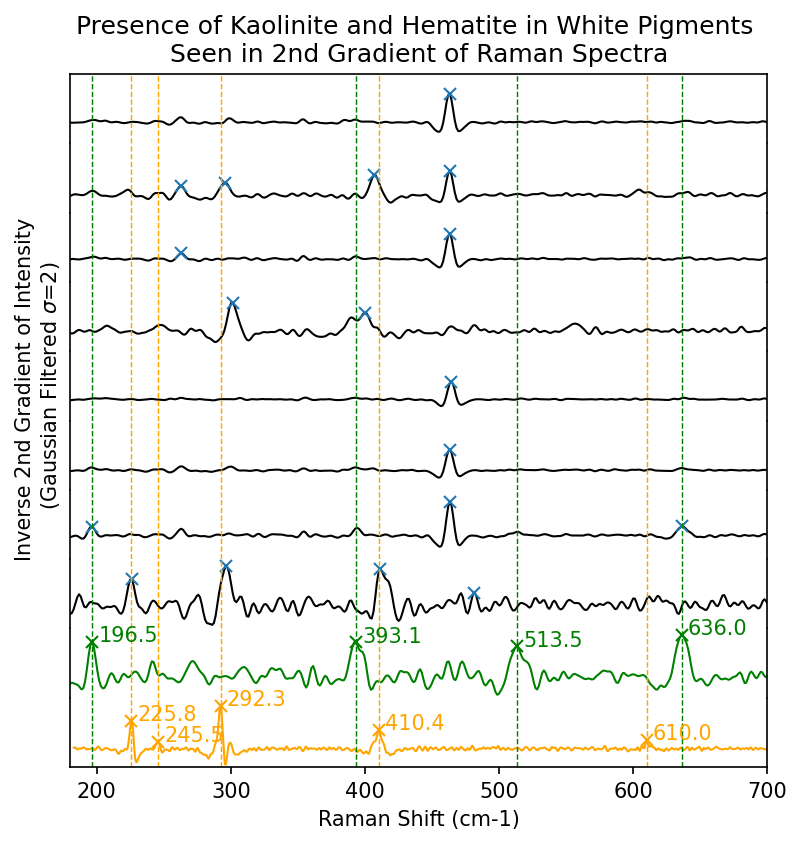

In [30]:
plt.rcParams['figure.dpi'] = 150
plt.figure(figsize=(6,6)) 
plt.subplots_adjust(hspace=0)

plt.subplot(10,1,1)
frame1 = plt.gca()
plt.plot(n1r,n1yy,c='Black',linewidth=1)
plt.plot(p21p,p21h,"x")
plt.xlim(180,700)
plt.ylim(-12,27)
plt.title('Presence of Kaolinite and Hematite in White Pigments \nSeen in 2nd Gradient of Raman Spectra')
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])
frame1.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,2)
frame2 = plt.gca()
plt.plot(n2r,n2yy,c='Black',linewidth=1)
plt.plot(p22p,p22h,"x")
plt.xlim(180,700)
plt.ylim(-6,17)
frame2.axes.get_yaxis().set_ticks([])
frame2.axes.get_xaxis().set_ticks([])
frame2.spines['top'].set_visible(False)
frame2.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,3)
frame3 = plt.gca()
plt.plot(n3r,n3yy,c='Black',linewidth=1)
plt.plot(p23p,p23h,"x")
plt.xlim(180,700)
plt.ylim(-10,20)
frame3.axes.get_yaxis().set_ticks([])
frame3.axes.get_xaxis().set_ticks([])
frame3.spines['top'].set_visible(False)
frame3.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,4)
frame4 = plt.gca()
plt.plot(n4ar,n4ayy,c='Black',linewidth=1)
plt.plot(p24ap,p24ah,"x")
plt.xlim(180,700)
plt.ylim(-3,7)
frame4.axes.get_yaxis().set_ticks([])
frame4.axes.get_xaxis().set_ticks([])
frame4.spines['top'].set_visible(False)
frame4.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,5)
frame5 = plt.gca()
plt.plot(n4br,n4byy,c='Black',linewidth=1)
plt.plot(p24bp,p24bh,"x")
plt.xlim(180,700)
plt.ylim(-12,27)
frame5.axes.get_yaxis().set_ticks([])
frame5.axes.get_xaxis().set_ticks([])
frame5.axes.get_xaxis().set_ticks([])
frame5.spines['top'].set_visible(False)
frame5.spines['bottom'].set_visible(False)
plt.ylabel('Inverse 2nd Gradient of Intensity \n(Gaussian Filtered $\\sigma$=2)')
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,6)
frame6 = plt.gca()
plt.plot(n5r,n5yy,c='Black',linewidth=1)
plt.plot(p25p,p25h,"x")
plt.xlim(180,700)
plt.ylim(-8,20)
frame6.axes.get_yaxis().set_ticks([])
frame6.axes.get_xaxis().set_ticks([])
frame6.spines['top'].set_visible(False)
frame6.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,7)
frame7 = plt.gca()
plt.plot(n6r,n6yy,c='Black',linewidth=1)
plt.plot(p26p,p26h,"x")
plt.xlim(180,700)
plt.ylim(-8,15)
frame7.axes.get_yaxis().set_ticks([])
frame7.axes.get_xaxis().set_ticks([])
frame7.spines['top'].set_visible(False)
frame7.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,8)
frame8 = plt.gca()
plt.plot(n7br,n7byy,c='Black',linewidth=1)
plt.plot(p27bp,p27bh,"x")
plt.xlim(180,700)
plt.ylim(-2.7,5)
frame8.axes.get_yaxis().set_ticks([])
frame8.axes.get_xaxis().set_ticks([])
frame8.spines['top'].set_visible(False)
frame8.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,9)
frame9 = plt.gca()
plt.plot(kr,kyy,linewidth=1,color='Green')
plt.plot(p2kp,p2kh,"x",color='Green')
for i,j in zip(p2kp,p2kh):
    plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(3,0),textcoords='offset points',color='Green')
plt.xlim(180,700)
plt.ylim(-3,6)
frame9.axes.get_yaxis().set_ticks([])
frame9.axes.get_xaxis().set_ticks([])
frame9.spines['top'].set_visible(False)
frame9.spines['bottom'].set_visible(False)
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')

plt.subplot(10,1,10)
frame10 = plt.gca()
plt.plot(hr,hyy,linewidth=1,color='Orange')
plt.plot(p2hp,p2hh,"x",color='Orange')
for i,j in zip(p2hp,p2hh):
    plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(3,0),textcoords='offset points',color='Orange')
plt.xlim(180,700)
plt.ylim(-20,55)
frame10.axes.get_yaxis().set_ticks([])
frame10.spines['top'].set_visible(False)
plt.xlabel('Raman Shift (cm-1)')
plt.axvline(x=225.8,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=245.5,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=292.3,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=410.4,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=610,color='Orange',linewidth=0.7,ls='--')
plt.axvline(x=196.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=393.1,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=513.5,color='Green',linewidth=0.7,ls='--')
plt.axvline(x=636,color='Green',linewidth=0.7,ls='--')